## Classifying Dietary Microplastic Exposure Risk Using Ensemble Machine Learning and SHAP-Based Explainable AI Across 109 Countries
This Colab notebook converts the research proposal into an executable data science workflow. The goal is to classify country-level dietary microplastic exposure risk using multi-country food exposure data, machine learning, temporal validation, and explainable AI.

Project scope from the proposal:

Dataset: microplastic exposure or consumption values from food categories in
more than 100 countries, covering 1990-2018.

Target: data-driven country risk classes for diet-based microplastic exposure.

Models: Multinomial Logistic Regression, Random Forest, and XGBoost.

Validation: stratified cross-validation and temporal holdout validation.

Interpretation: feature importance, permutation importance, and optional SHAP analysis.

Prototype: a reusable risk prediction function for decision-support experiments.

Dataset URL: https://www.kaggle.com/datasets/jayeshrmohanan/dataset-for-microplastic-consumption-in-food-items

# Importing Libraries

In [ ]:
!pip install xgboost shap imbalanced-learn scikit-learn pandas numpy matplotlib seaborn -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, cross_validate)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# XGBoost
from xgboost import XGBClassifier

# Imbalanced
from imblearn.over_sampling import SMOTE

# SHAP
import shap

# Misc
from itertools import cycle

print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Loading Datasets

In [ ]:
import pandas as pd

# Processed microplastics data
processed_file = '/content/drive/MyDrive/processed_microplastics.csv'
try:
    df = pd.read_csv(processed_file, encoding='ascii')
    print('Processed microplastics data loaded successfully.')
except Exception as e:
    print(f'Error loading processed_microplastics.csv: {e}')

# Train dataset
train_file = '/content/drive/MyDrive/train.csv'
try:
    train_df = pd.read_csv(train_file, encoding='utf-8-sig')
    print('Train data loaded successfully.')
except Exception as e:
    print(f'Error loading train.csv: {e}')


Processed microplastics data loaded successfully.
Train data loaded successfully.


In [ ]:
print("=" * 60)
print("PROCESSED DATASET — OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
display(df.head())

print("\n" + "=" * 60)
print("TRAIN DATASET — OVERVIEW")
print("=" * 60)
print(f"Shape: {train_df.shape}")
print(f"\nFirst 5 rows:")
display(train_df.head())

PROCESSED DATASET — OVERVIEW
Shape: (723, 21)

Data types:
year                          int64
country                      object
cheese                      float64
yoghurt                     float64
total_milk                  float64
fruits                      float64
refined_grains              float64
whole_grains                float64
nuts_and_seeds              float64
total_processed_meats       float64
unprocessed_red_meats       float64
fish                        float64
shellfish                   float64
eggs                        float64
total_salt                  float64
added_sugars                float64
non-starchy_vegetables      float64
potatoes                    float64
other_starchy_vegetables    float64
beans_and_legumes           float64
total_ug_per_kg             float64
dtype: object

First 5 rows:


,year,country,cheese,yoghurt,total_milk,fruits,refined_grains,whole_grains,nuts_and_seeds,total_processed_meats,...,fish,shellfish,eggs,total_salt,added_sugars,non-starchy_vegetables,potatoes,other_starchy_vegetables,beans_and_legumes,total_ug_per_kg
0,1990,Angola,0.191781,54.899739,96.602740,76.520548,481.297149,44.309838,2.849315,22.770109,...,53.013699,0.164384,1.041096,8.005259,32.547945,80.164384,8.109589,39.342466,19.835616,1043.279108
1,1990,Benin,0.054795,9.365946,18.410959,90.876712,534.256965,48.836323,19.561644,17.018264,...,18.794521,3.972603,2.849315,5.854497,8.246575,122.986301,0.000000,304.904110,21.178082,1241.656197
2,1990,Burkina Faso,0.273973,35.390618,56.027397,19.178082,213.170183,129.416119,28.465753,9.541329,...,4.684932,0.000000,6.767123,6.928378,9.534247,64.767123,2.219178,13.780822,32.520548,666.603927
3,1990,Central African Republic,0.000000,19.206478,48.000000,113.397260,285.035375,302.567776,23.506849,26.412094,...,13.917808,0.000000,1.123288,6.585071,19.698630,101.753425,0.575342,209.452055,12.821918,1237.339905
4,1990,Cote D'Ivoire,0.301370,2.220447,38.109589,37.013699,436.907598,25.220347,16.904110,2.459103,...,51.424658,0.493151,2.438356,9.660915,28.438356,151.150685,1.945205,676.575343,2.356164,1540.502458



TRAIN DATASET — OVERVIEW
Shape: (723, 20)

First 5 rows:


,Year,Country,Cheese,Yoghurt,Total Milk,Fruits,Refined Grains,Whole Grains,Nuts And Seeds,Total Processed Meats,Unprocessed Red Meats,Fish,Shellfish,Eggs,Total Salt,Added Sugars,Non-Starchy Vegetables,Potatoes,Other Starchy Vegetables,Beans And Legumes
0,1990,Angola,0.191781,54.899739,96.602740,76.520548,481.297149,44.309838,2.849315,22.770109,21.613452,53.013699,0.164384,1.041096,8.005259,32.547945,80.164384,8.109589,39.342466,19.835616
1,1990,Benin,0.054795,9.365946,18.410959,90.876712,534.256965,48.836323,19.561644,17.018264,14.488586,18.794521,3.972603,2.849315,5.854497,8.246575,122.986301,0.000000,304.904110,21.178082
2,1990,Burkina Faso,0.273973,35.390618,56.027397,19.178082,213.170183,129.416119,28.465753,9.541329,33.938123,4.684932,0.000000,6.767123,6.928378,9.534247,64.767123,2.219178,13.780822,32.520548
3,1990,Central African Republic,0.000000,19.206478,48.000000,113.397260,285.035375,302.567776,23.506849,26.412094,53.286536,13.917808,0.000000,1.123288,6.585071,19.698630,101.753425,0.575342,209.452055,12.821918
4,1990,Cote d'Ivoire,0.301370,2.220447,38.109589,37.013699,436.907598,25.220347,16.904110,2.459103,56.883363,51.424658,0.493151,2.438356,9.660915,28.438356,151.150685,1.945205,676.575343,2.356164


# Missing Value Analysis

In [ ]:
def missing_value_report(dataframe, name="Dataset"):
    missing = dataframe.isnull().sum()
    missing_pct = (missing / len(dataframe)) * 100
    report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
    report = report[report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
    print(f"\n{name} — Missing Value Report")
    print("=" * 50)
    if report.empty:
        print("No missing values found.")
    else:
        print(report)
    return report

missing_df = missing_value_report(df, "Processed Dataset")
missing_train = missing_value_report(train_df, "Train Dataset")



Processed Dataset — Missing Value Report
No missing values found.

Train Dataset — Missing Value Report
No missing values found.


# Exploratory Data Analysis (EDA)

In [ ]:
print("Statistical Summary — Processed Dataset")
display(df.describe())

Statistical Summary — Processed Dataset


,year,cheese,yoghurt,total_milk,fruits,refined_grains,whole_grains,nuts_and_seeds,total_processed_meats,unprocessed_red_meats,fish,shellfish,eggs,total_salt,added_sugars,non-starchy_vegetables,potatoes,other_starchy_vegetables,beans_and_legumes,total_ug_per_kg
count,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000
mean,2005.113416,6.135622,54.175691,250.655223,198.891339,310.733750,76.090720,12.716421,43.242799,90.326727,40.367154,7.415298,17.184714,6.844069,87.980939,232.405995,81.885598,64.300877,19.261638,1600.614574
std,9.610611,10.437505,77.868834,243.250670,150.271271,138.658231,81.578881,10.827892,39.223624,67.646655,34.835918,13.695479,14.584195,1.806978,60.331304,164.633624,83.109875,135.136514,16.758578,567.115360
min,1990.000000,0.000000,0.748435,1.808219,8.958904,72.797775,0.158798,0.000000,0.396227,6.583087,0.054795,0.000000,0.027397,2.278036,3.972603,16.931507,0.000000,0.000000,0.438356,440.261767
25%,1995.000000,0.273973,12.048883,50.342466,89.808219,216.258939,16.965904,4.561644,11.560798,33.837311,15.726027,0.191781,3.876712,5.845209,38.753425,118.287671,12.205479,0.493151,7.821918,1176.251294
50%,2005.000000,1.424658,35.390618,153.506849,179.945205,288.254183,47.164800,9.589041,29.473811,71.678223,31.232877,1.589041,13.780822,6.660399,83.698630,185.945205,49.561644,8.547945,14.794521,1550.939573
75%,2015.000000,6.082192,73.449547,400.890411,266.863014,383.983087,101.764947,18.410959,66.736055,134.673403,54.506849,8.630137,27.657534,7.659304,117.616438,292.479452,135.876712,59.123288,25.561644,2061.390253
max,2018.000000,65.643836,679.834239,1040.931507,1078.931507,890.394188,434.121124,73.068493,198.333731,477.301388,207.315068,151.863014,61.698630,12.430686,453.780822,1055.342466,362.712329,833.945206,124.575343,3613.131482


# Distributions by Food Category

Food category columns identified: ['cheese', 'yoghurt', 'total_milk', 'fruits', 'refined_grains', 'whole_grains', 'nuts_and_seeds', 'total_processed_meats', 'unprocessed_red_meats', 'fish', 'shellfish', 'eggs', 'total_salt', 'added_sugars', 'non-starchy_vegetables', 'potatoes', 'other_starchy_vegetables', 'beans_and_legumes', 'total_ug_per_kg']


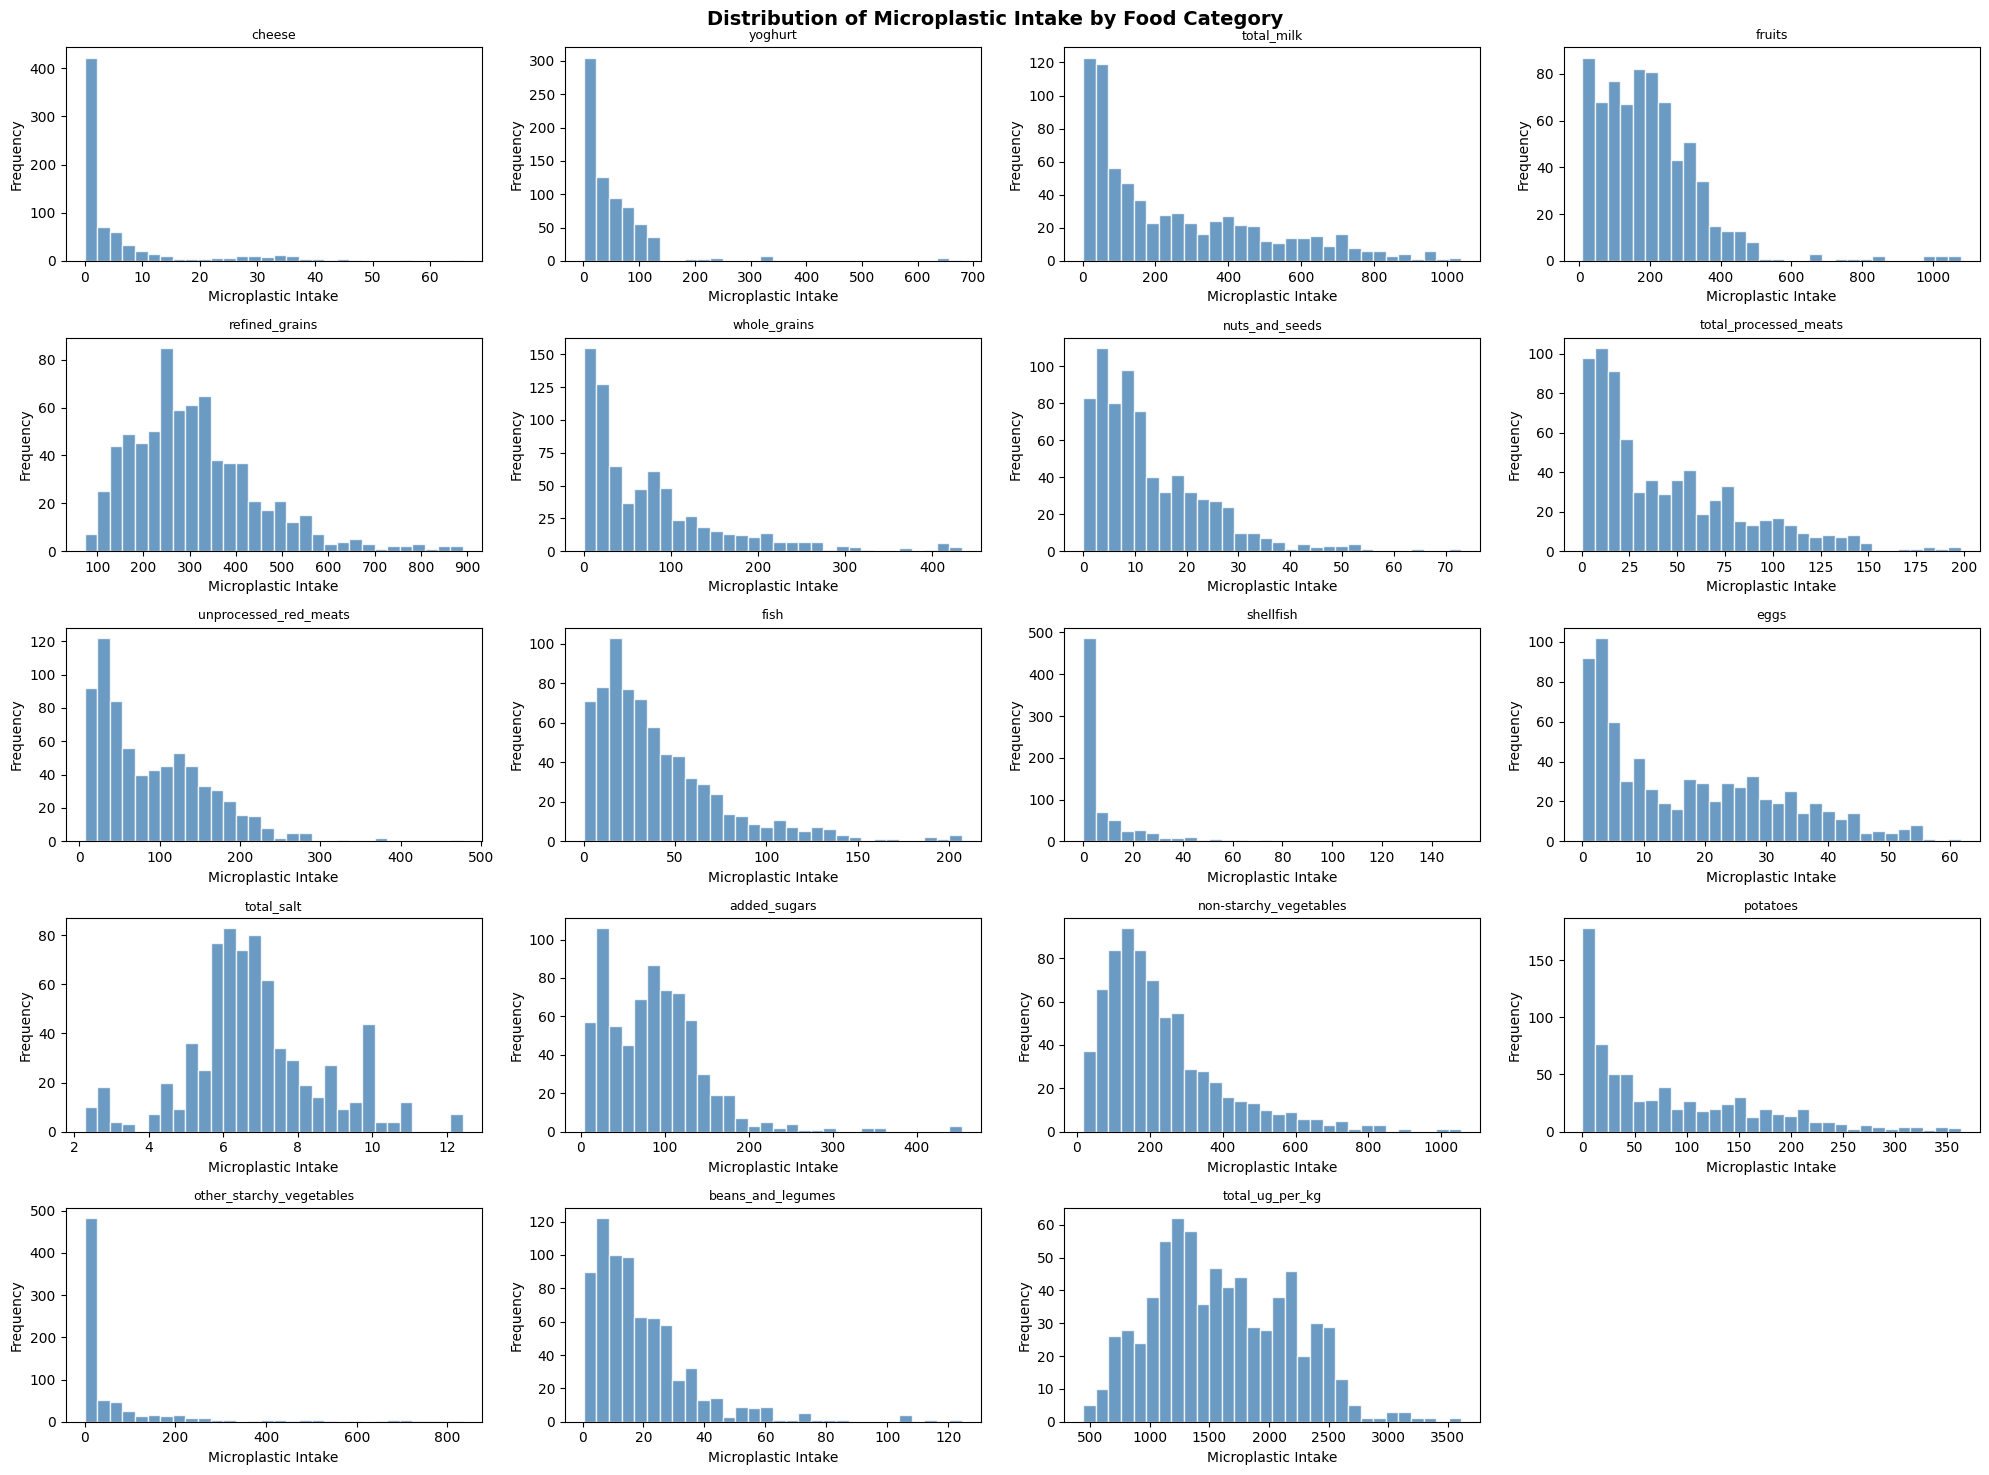

In [ ]:
exclude_cols = ['country', 'Country', 'year', 'Year', 'iso', 'ISO', 'id', 'ID', 'risk_class']
food_cols = [c for c in df.select_dtypes(include=[np.number]).columns
             if c.lower() not in [e.lower() for e in exclude_cols]]

print(f"Food category columns identified: {food_cols}")

if food_cols:
    n_cols = 4
    n_rows = (len(food_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
    axes = axes.flatten()

    for i, col in enumerate(food_cols):
        axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xlabel('Microplastic Intake')
        axes[i].set_ylabel('Frequency')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Distribution of Microplastic Intake by Food Category', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# EDA — Temporal Trends (1990–2018)

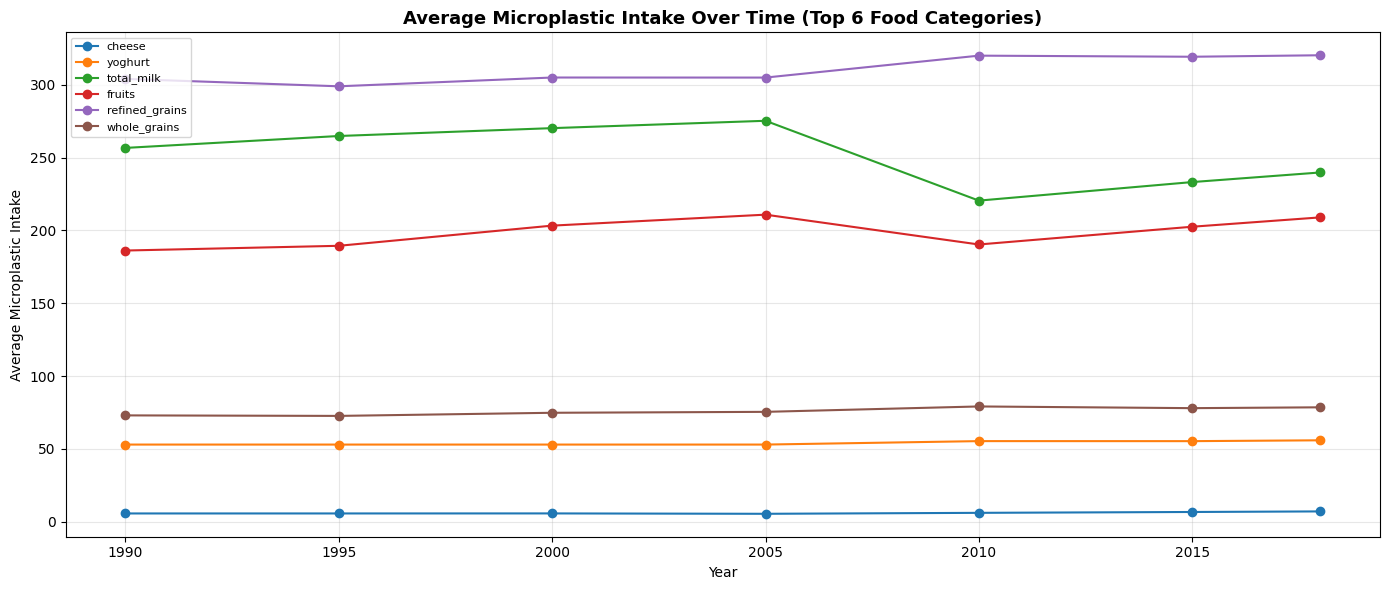

In [ ]:
year_col = None
for c in df.columns:
    if c.lower() == 'year':
        year_col = c
        break

if year_col and food_cols:
    yearly_avg = df.groupby(year_col)[food_cols].mean()

    plt.figure(figsize=(14, 6))
    for col in food_cols[:6]:
        plt.plot(yearly_avg.index, yearly_avg[col], marker='o', linewidth=1.5, label=col)

    plt.title('Average Microplastic Intake Over Time (Top 6 Food Categories)', fontsize=13, fontweight='bold')
    plt.xlabel('Year')
    plt.ylabel('Average Microplastic Intake')
    plt.legend(loc='upper left', fontsize=8)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Year column not found or no food columns identified.")

# Correlation Heatmap

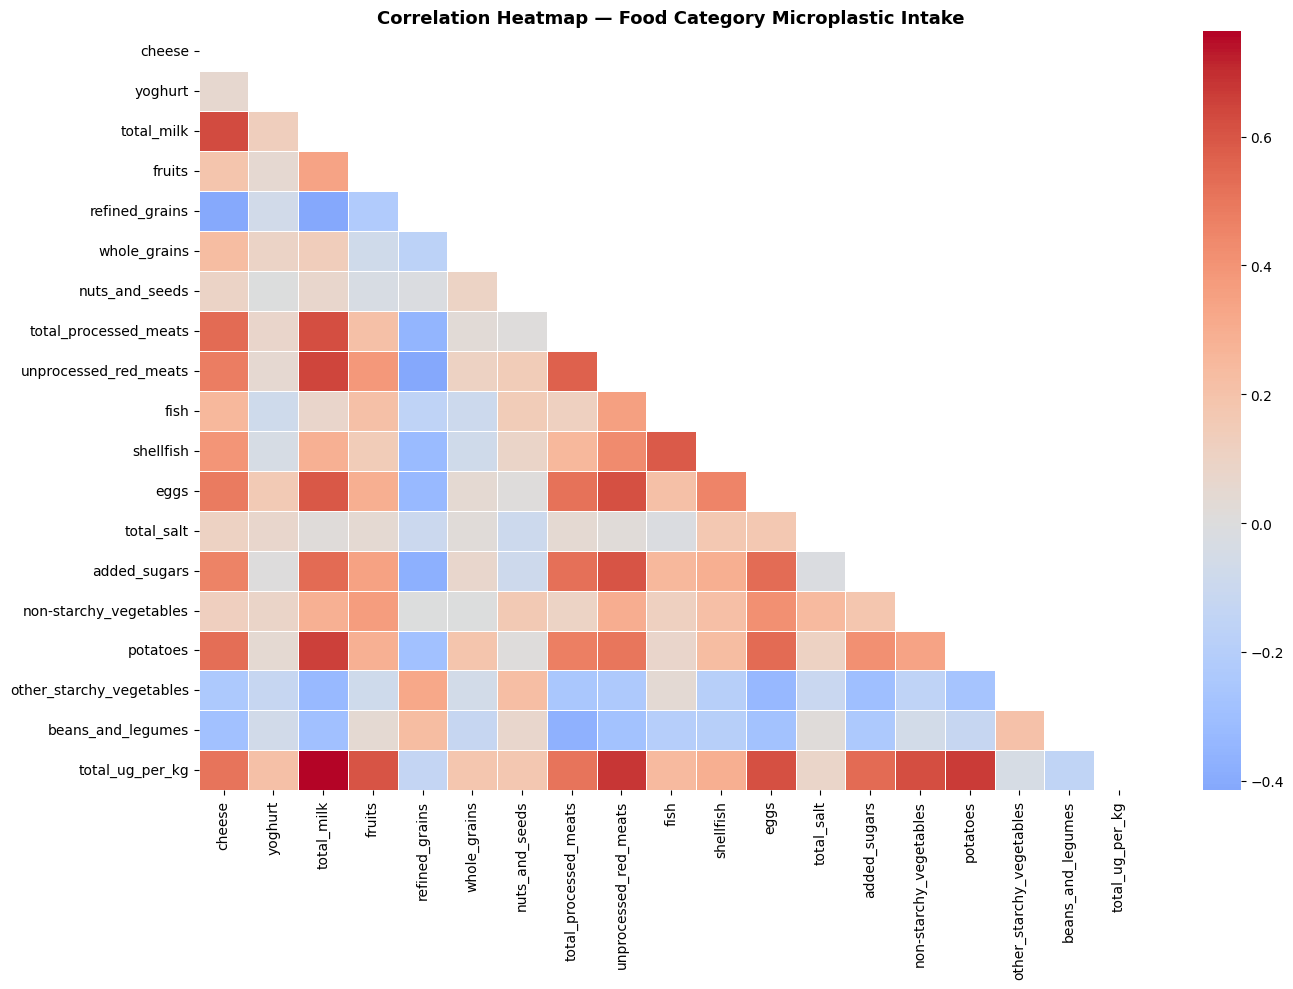

In [ ]:
if food_cols:
    corr_matrix = df[food_cols].corr()

    plt.figure(figsize=(14, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
                center=0, linewidths=0.5, fmt='.2f')
    plt.title('Correlation Heatmap — Food Category Microplastic Intake', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Top Countries by Total Microplastic Intake

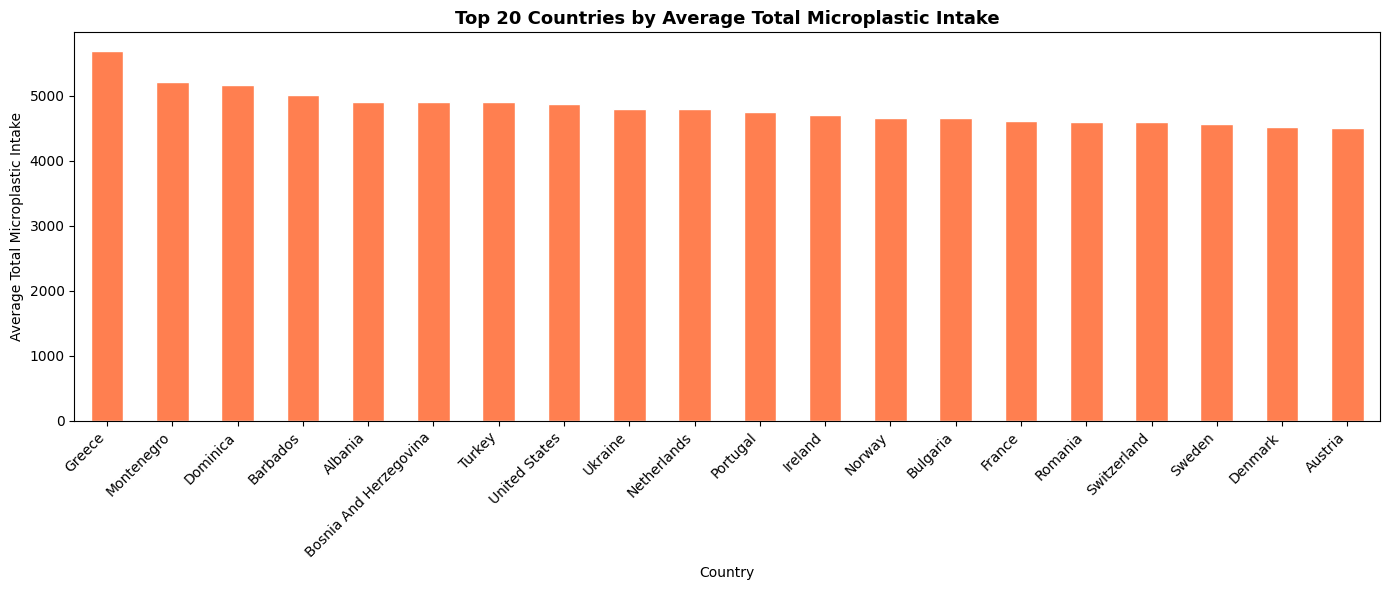

In [ ]:
country_col = None
for c in df.columns:
    if c.lower() in ['country', 'country_name']:
        country_col = c
        break

if country_col and food_cols:
    df['total_intake'] = df[food_cols].sum(axis=1)
    country_avg = df.groupby(country_col)['total_intake'].mean().sort_values(ascending=False).head(20)

    plt.figure(figsize=(14, 6))
    country_avg.plot(kind='bar', color='coral', edgecolor='white')
    plt.title('Top 20 Countries by Average Total Microplastic Intake', fontsize=13, fontweight='bold')
    plt.xlabel('Country')
    plt.ylabel('Average Total Microplastic Intake')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Country column not found.")

# Data Preprocessing

In [ ]:
df_clean = df.copy()

for col in food_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

print(f"Missing values after imputation: {df_clean[food_cols].isnull().sum().sum()}")


df_clean['total_intake'] = df_clean[food_cols].sum(axis=1)
df_clean['mean_intake'] = df_clean[food_cols].mean(axis=1)
df_clean['std_intake'] = df_clean[food_cols].std(axis=1)
df_clean['max_intake'] = df_clean[food_cols].max(axis=1)


marine_cols = [c for c in food_cols if any(k in c.lower() for k in ['fish', 'seafood', 'marine', 'shellfish'])]
if marine_cols:
    df_clean['marine_ratio'] = df_clean[marine_cols].sum(axis=1) / (df_clean['total_intake'] + 1e-9)
    print(f"Marine columns identified: {marine_cols}")

print(f"\nNew features added: total_intake, mean_intake, std_intake, max_intake")
print(f"Dataset shape after feature engineering: {df_clean.shape}")

Missing values after imputation: 0
Marine columns identified: ['fish', 'shellfish']

New features added: total_intake, mean_intake, std_intake, max_intake
Dataset shape after feature engineering: (723, 26)


# Normalisation / Scaling

In [ ]:
engineered_features = ['total_intake', 'mean_intake', 'std_intake', 'max_intake']
if marine_cols:
    engineered_features.append('marine_ratio')

all_feature_cols = food_cols + engineered_features

scaler = StandardScaler()
df_scaled = df_clean.copy()
df_scaled[all_feature_cols] = scaler.fit_transform(df_clean[all_feature_cols])

print("Standard scaling applied to all numeric feature columns.")
print(f"Feature matrix shape: {df_scaled[all_feature_cols].shape}")


Standard scaling applied to all numeric feature columns.
Feature matrix shape: (723, 24)


# Dimensionality Reduction & Visualization

Explained variance ratio (PC1, PC2): [0.39266289 0.11343945]
Total variance explained: 0.506


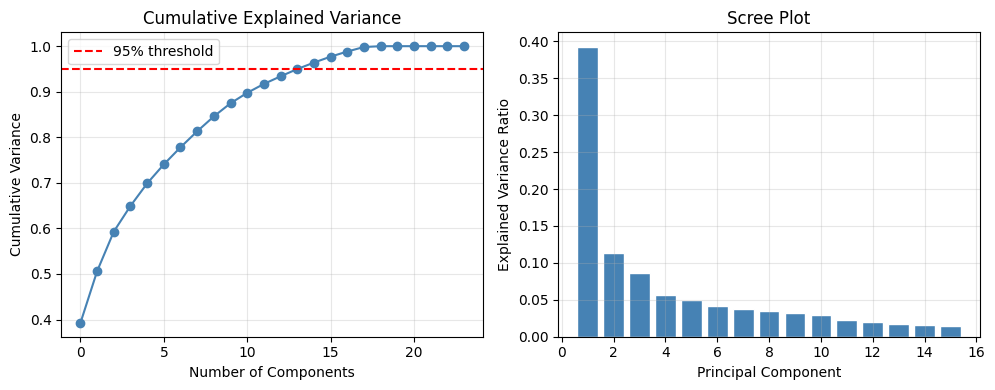

In [ ]:
X_for_pca = df_scaled[all_feature_cols].dropna()

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_for_pca)

print(f"Explained variance ratio (PC1, PC2): {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.3f}")


pca_full = PCA(random_state=42)
pca_full.fit(X_for_pca)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o', color='steelblue')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)

num_components_to_plot = min(15, len(pca_full.explained_variance_ratio_))
plt.bar(range(1, num_components_to_plot + 1),
        pca_full.explained_variance_ratio_[:num_components_to_plot], color='steelblue', edgecolor='white')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# K-Means Clustering — Risk Class Creation

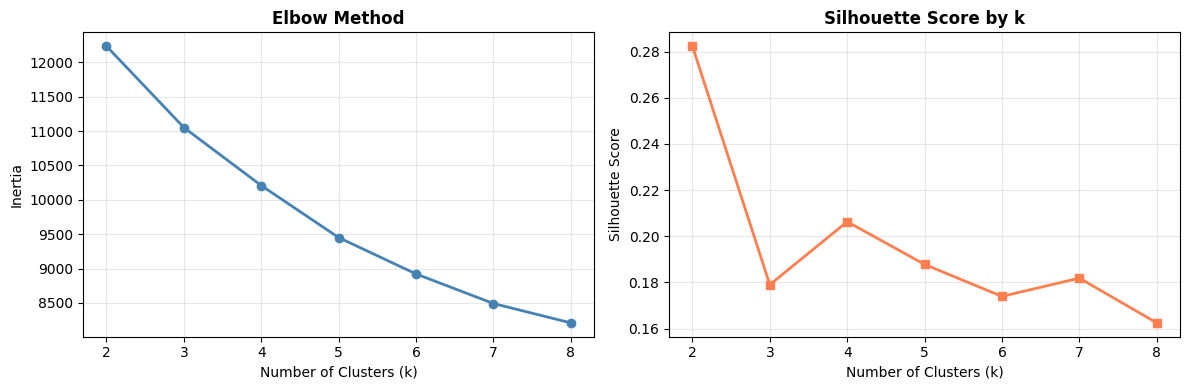


Best k by silhouette score: 2 (score = 0.2823)


In [ ]:
from sklearn.metrics import silhouette_score

X_cluster = df_scaled[all_feature_cols].dropna().values

inertias = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(k_range, silhouette_scores, marker='s', color='coral', linewidth=2)
axes[1].set_title('Silhouette Score by k', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBest k by silhouette score: {k_range[np.argmax(silhouette_scores)]} "
      f"(score = {max(silhouette_scores):.4f})")

# K-Means — Assign Risk Labels (Low / Medium / High)

Risk class distribution:
risk_label
Low       312
Medium    229
High      182
Name: count, dtype: int64


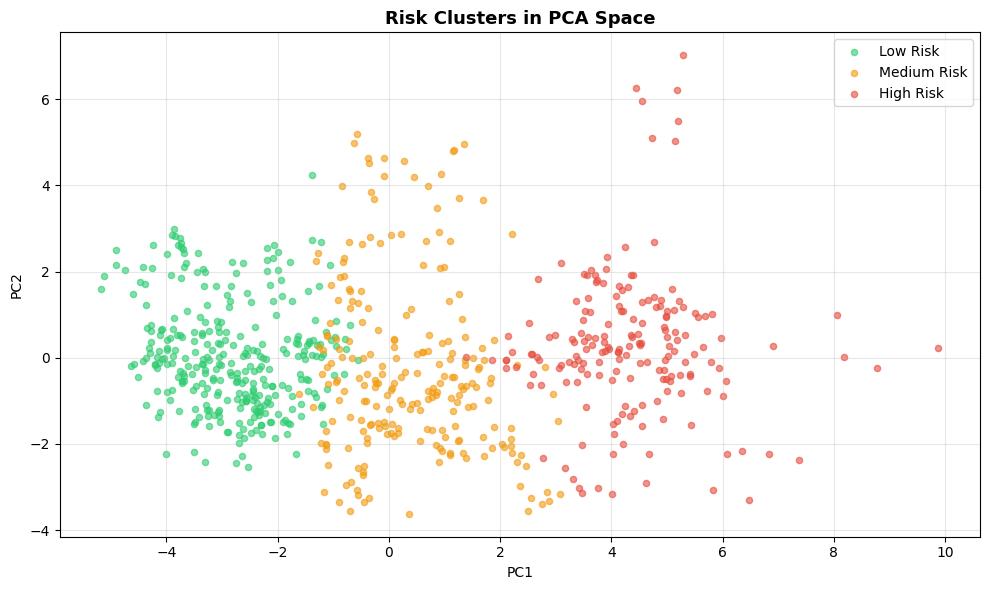

In [ ]:
OPTIMAL_K = 3

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

valid_idx = df_clean[all_feature_cols].dropna().index
df_clean.loc[valid_idx, 'cluster'] = cluster_labels

cluster_means = df_clean.groupby('cluster')['total_intake'].mean().sort_values()
risk_map = {cluster_means.index[0]: 0,   # Low
            cluster_means.index[1]: 1,   # Medium
            cluster_means.index[2]: 2}   # High

df_clean['risk_class'] = df_clean['cluster'].map(risk_map)

label_names = {0: 'Low', 1: 'Medium', 2: 'High'}
df_clean['risk_label'] = df_clean['risk_class'].map(label_names)

print("Risk class distribution:")
print(df_clean['risk_label'].value_counts())

# Visualizing clusters in PCA space
plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#f39c12', '#e74c3c']
risk_labels_arr = df_clean.loc[valid_idx, 'risk_label'].values

for i, (risk, color) in enumerate(zip(['Low', 'Medium', 'High'], colors)):
    mask = risk_labels_arr == risk
    plt.scatter(pca_coords[mask, 0], pca_coords[mask, 1],
                c=color, label=f'{risk} Risk', alpha=0.6, s=20)

plt.title('Risk Clusters in PCA Space', fontsize=13, fontweight='bold')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Prepare Final Feature Matrix & Target

In [ ]:
df_model = df_clean[all_feature_cols + ['risk_class']].dropna()

X = df_model[all_feature_cols].values
y = df_model['risk_class'].values.astype(int)

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{pd.Series(y).map(label_names).value_counts()}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")


Feature matrix shape: (723, 24)
Target distribution:
Low       312
Medium    229
High      182
Name: count, dtype: int64

Train size: 578 | Test size: 145


# Handle Class Imbalance with SMOTE

In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
unique, counts = np.unique(y_train_res, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_names[u]}: {c}")

Class distribution after SMOTE:
  Low: 249
  Medium: 249
  High: 249


# Model 1 — Multinomial Logistic Regression (Baseline)

In [ ]:
lr_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_res, y_train_res)
y_pred_lr = lr_model.predict(X_test)

print("Multinomial Logistic Regression — Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_lr, target_names=['Low', 'Medium', 'High']))

Multinomial Logistic Regression — Classification Report
              precision    recall  f1-score   support

         Low       0.93      0.79      0.85        63
      Medium       0.74      0.91      0.82        46
        High       1.00      0.94      0.97        36

    accuracy                           0.87       145
   macro avg       0.89      0.88      0.88       145
weighted avg       0.88      0.87      0.87       145



# Model 2 — Random Forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_res, y_train_res)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest — Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_rf, target_names=['Low', 'Medium', 'High']))


Random Forest — Classification Report
              precision    recall  f1-score   support

         Low       0.98      1.00      0.99        63
      Medium       0.98      0.98      0.98        46
        High       1.00      0.97      0.99        36

    accuracy                           0.99       145
   macro avg       0.99      0.98      0.99       145
weighted avg       0.99      0.99      0.99       145



# Model 3 — XGBoost

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_res, y_train_res)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost — Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_xgb, target_names=['Low', 'Medium', 'High']))

XGBoost — Classification Report
              precision    recall  f1-score   support

         Low       0.98      0.97      0.98        63
      Medium       0.94      0.98      0.96        46
        High       1.00      0.97      0.99        36

    accuracy                           0.97       145
   macro avg       0.97      0.97      0.97       145
weighted avg       0.97      0.97      0.97       145



# Model Evaluation — Performance Comparison


Model Performance Comparison


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8690,0.8843,0.8690,0.8713,0.9695
Random Forest,0.9862,0.9863,0.9862,0.9862,0.9996
XGBoost,0.9724,0.9732,0.9724,0.9726,0.9993


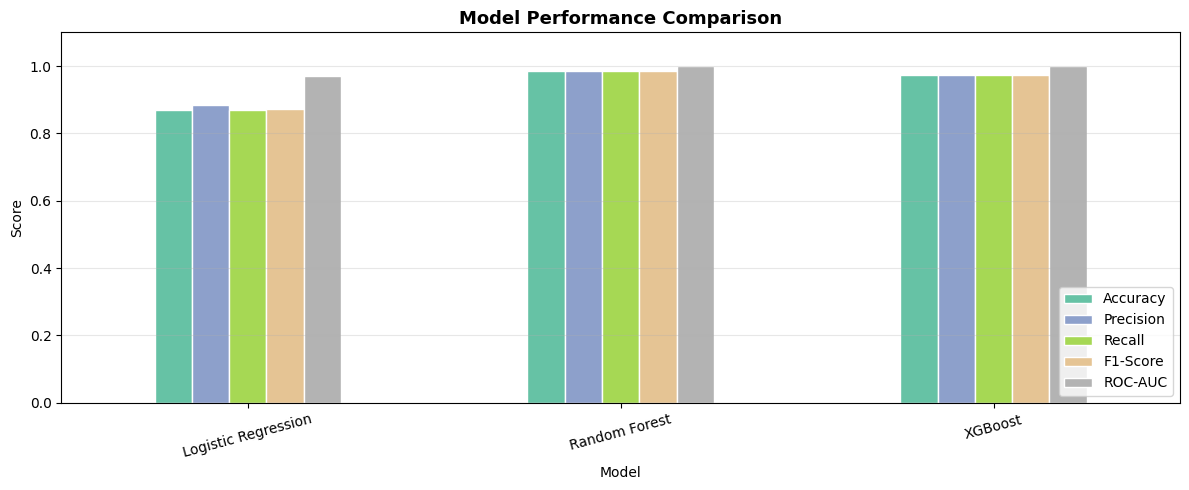

In [ ]:
def evaluate_model(name, y_true, y_pred, model, X_test_data):
    acc   = accuracy_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec   = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1    = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    y_prob = model.predict_proba(X_test_data)
    y_bin  = label_binarize(y_true, classes=[0, 1, 2])
    auc    = roc_auc_score(y_bin, y_prob, average='weighted', multi_class='ovr')

    return {'Model': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc}

results = [
    evaluate_model('Logistic Regression', y_test, y_pred_lr, lr_model, X_test),
    evaluate_model('Random Forest',       y_test, y_pred_rf, rf_model, X_test),
    evaluate_model('XGBoost',             y_test, y_pred_xgb, xgb_model, X_test),
]

results_df = pd.DataFrame(results).set_index('Model').round(4)
print("\nModel Performance Comparison")
print("=" * 60)
display(results_df)

# Bar chart comparison
results_df.plot(kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='white')
plt.title('Model Performance Comparison', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion Matrices

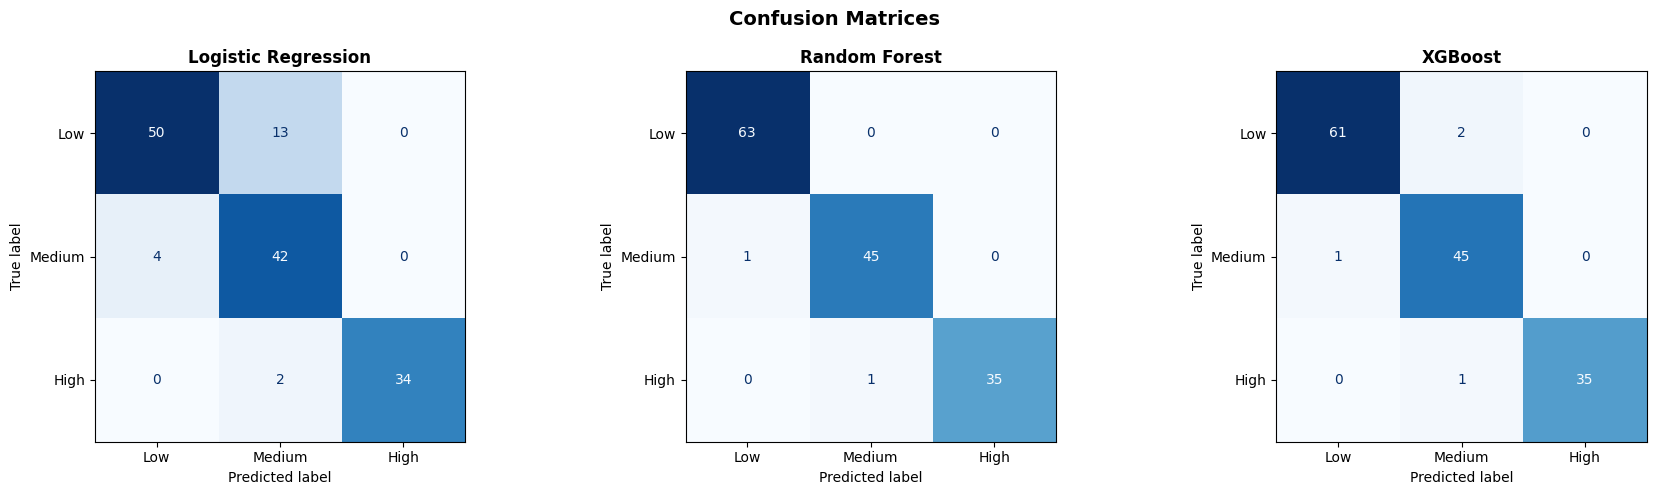

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_preds = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest',       y_pred_rf),
    ('XGBoost',             y_pred_xgb),
]

for ax, (name, y_pred) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Low', 'Medium', 'High'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Stratified K-Fold Cross-Validation

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted']

cv_models = {
    'Logistic Regression': lr_model,
    'Random Forest':       rf_model,
    'XGBoost':             xgb_model,
}

cv_results = {}
for model_name, model in cv_models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[model_name] = {
        'Accuracy':  scores['test_accuracy'].mean(),
        'F1-Score':  scores['test_f1_weighted'].mean(),
        'Precision': scores['test_precision_weighted'].mean(),
        'Recall':    scores['test_recall_weighted'].mean(),
        'Acc Std':   scores['test_accuracy'].std(),
    }

cv_df = pd.DataFrame(cv_results).T.round(4)
print("\n5-Fold Cross-Validation Results")
print("=" * 60)
display(cv_df)


5-Fold Cross-Validation Results


,Accuracy,F1-Score,Precision,Recall,Acc Std
Logistic Regression,0.8824,0.8823,0.8834,0.8824,0.0301
Random Forest,0.9723,0.9723,0.9726,0.9723,0.0145
XGBoost,0.9668,0.9666,0.9673,0.9668,0.0178


# Temporal Validation

In [ ]:
year_col_clean = None
for c in df_clean.columns:
    if c.lower() == 'year':
        year_col_clean = c
        break

if year_col_clean:
    df_temporal = df_clean[all_feature_cols + ['risk_class', year_col_clean]].dropna()
    SPLIT_YEAR = 2010

    train_mask = df_temporal[year_col_clean] <= SPLIT_YEAR
    test_mask  = df_temporal[year_col_clean]  > SPLIT_YEAR

    X_temp_train = df_temporal.loc[train_mask, all_feature_cols].values
    y_temp_train = df_temporal.loc[train_mask, 'risk_class'].values.astype(int)
    X_temp_test  = df_temporal.loc[test_mask,  all_feature_cols].values
    y_temp_test  = df_temporal.loc[test_mask,  'risk_class'].values.astype(int)

    print(f"Temporal split: Train ≤ {SPLIT_YEAR} ({len(y_temp_train)} samples) | "
          f"Test > {SPLIT_YEAR} ({len(y_temp_test)} samples)")

    smote_temp = SMOTE(random_state=42)
    X_temp_res, y_temp_res = smote_temp.fit_resample(X_temp_train, y_temp_train)

    temporal_results = {}
    for model_name, ModelClass, params in [
        ('Logistic Regression', LogisticRegression,
         {'multi_class': 'multinomial', 'solver': 'lbfgs', 'max_iter': 1000, 'random_state': 42}),
        ('Random Forest', RandomForestClassifier,
         {'n_estimators': 200, 'random_state': 42, 'n_jobs': -1}),
        ('XGBoost', XGBClassifier,
         {'n_estimators': 300, 'learning_rate': 0.05, 'use_label_encoder': False,
          'eval_metric': 'mlogloss', 'random_state': 42, 'n_jobs': -1}),
    ]:
        m = ModelClass(**params)
        m.fit(X_temp_res, y_temp_res)
        y_tp = m.predict(X_temp_test)
        temporal_results[model_name] = {
            'Accuracy':  round(accuracy_score(y_temp_test, y_tp), 4),
            'F1-Score':  round(f1_score(y_temp_test, y_tp, average='weighted', zero_division=0), 4),
            'Precision': round(precision_score(y_temp_test, y_tp, average='weighted', zero_division=0), 4),
            'Recall':    round(recall_score(y_temp_test, y_tp, average='weighted', zero_division=0), 4),
        }

    temporal_df = pd.DataFrame(temporal_results).T
    print("\nTemporal Validation Results (Train ≤ 2010 → Test > 2010)")
    print("=" * 60)
    display(temporal_df)
else:
    print("Year column not found in dataset — temporal validation skipped.")

Temporal split: Train ≤ 2010 (505 samples) | Test > 2010 (218 samples)

Temporal Validation Results (Train ≤ 2010 → Test > 2010)


,Accuracy,F1-Score,Precision,Recall
Logistic Regression,0.8807,0.8805,0.8804,0.8807
Random Forest,0.9495,0.9495,0.9525,0.9495
XGBoost,0.9404,0.9411,0.9471,0.9404


# Feature Importance — Random Forest & XGBoost

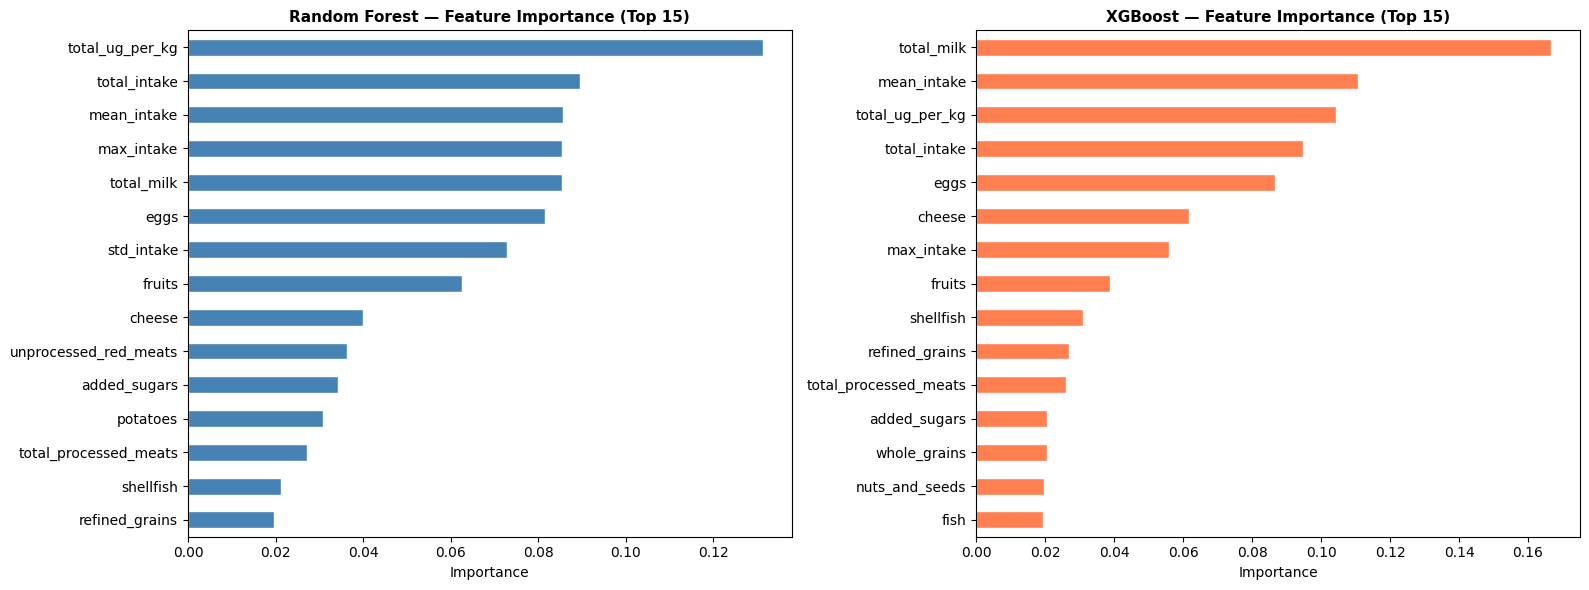

In [ ]:
feature_names = all_feature_cols

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
rf_importance = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=True).tail(15)
rf_importance.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Random Forest — Feature Importance (Top 15)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Importance')

# XGBoost
xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values(ascending=True).tail(15)
xgb_importance.plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('XGBoost — Feature Importance (Top 15)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

# Explainable AI — SHAP Analysis (XAI)

Best tree-based model selected for SHAP: Random Forest (F1 = 0.9862)


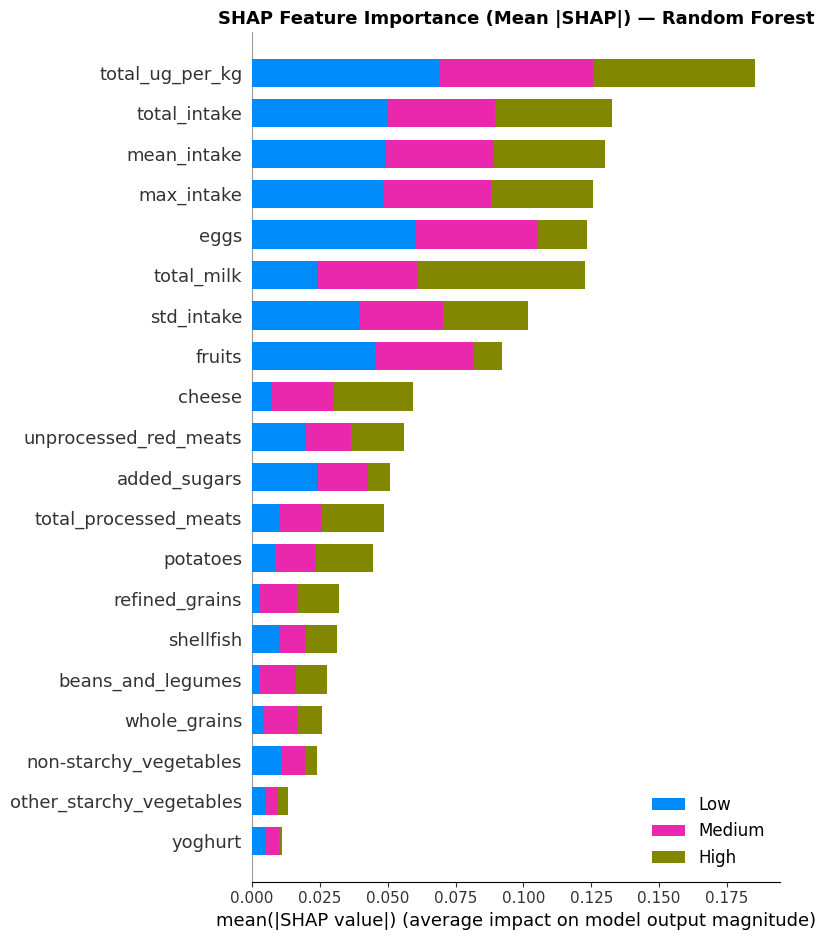

In [ ]:
# Dynamically select best model by F1-Score (Random Forest or XGBoost)
tree_models = {
    'Random Forest': rf_model,
    'XGBoost':       xgb_model,
}
best_tree_name = results_df.loc[list(tree_models.keys()), 'F1-Score'].idxmax()
best_tree_model = tree_models[best_tree_name]

print(f"Best tree-based model selected for SHAP: {best_tree_name} "
      f"(F1 = {results_df.loc[best_tree_name, 'F1-Score']:.4f})")

explainer = shap.TreeExplainer(best_tree_model)
shap_values = explainer.shap_values(X_test)


if not isinstance(shap_values, list):
    shap_values = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

# SHAP Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=feature_names,
                  plot_type='bar', class_names=['Low', 'Medium', 'High'], show=False)
plt.title(f'SHAP Feature Importance (Mean |SHAP|) — {best_tree_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Dependence Plot (Most Important Feature)

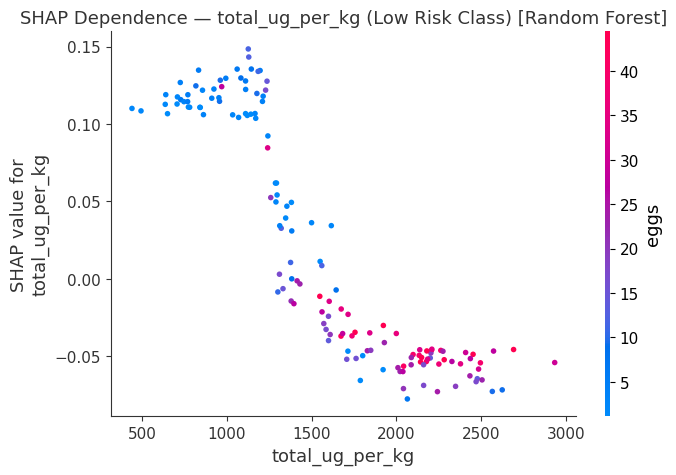

<Figure size 640x480 with 0 Axes>

Top feature by SHAP: total_ug_per_kg


In [ ]:
mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
top_feature_idx = np.argmax(mean_abs_shap)
top_feature_name = feature_names[top_feature_idx]

# Dependence plot on the Low-risk class
shap.dependence_plot(
    top_feature_idx,
    shap_values[0],
    X_test,
    feature_names=feature_names,
    title=f'SHAP Dependence — {top_feature_name} (Low Risk Class) [{best_tree_name}]'
)
plt.tight_layout()
plt.show()

print(f"Top feature by SHAP: {top_feature_name}")

# Final Results Summary

In [ ]:
print("\n[1] Dataset Info")
print(f"    Total records      : {df_clean.shape[0]}")
print(f"    Feature columns    : {len(all_feature_cols)}")
print(f"    Countries covered  : {df_clean[country_col].nunique() if country_col else 'N/A'}")
print(f"    Year range         : 1990 – 2018")

print("\n[2] Risk Class Distribution")
for label, count in df_clean['risk_label'].value_counts().items():
    pct = count / df_clean.shape[0] * 100
    print(f"    {label:<10}: {count:>5}  ({pct:.1f}%)")

print("\n[3] Standard Evaluation Results")
display(results_df)

print("\n[4] 5-Fold Cross-Validation Results")
display(cv_df)

if year_col_clean:
    print("\n[5] Temporal Validation Results (≤2010 → >2010)")
    display(temporal_df)

print("\n[6] Best Performing Model")
best_model = results_df['F1-Score'].idxmax()
best_f1    = results_df.loc[best_model, 'F1-Score']
best_auc   = results_df.loc[best_model, 'ROC-AUC']
print(f"    Model   : {best_model}")
print(f"    F1-Score: {best_f1:.4f}")
print(f"    ROC-AUC : {best_auc:.4f}")

print("\n[7] Hypothesis Evaluation")
hypotheses = {
    'H1': 'ML models outperform traditional statistical methods',
    'H2': 'Feature optimization improves model performance',
    'H3': 'K-means derived risk classes can be learned by ML models',
    'H4': 'Ensemble methods (RF, XGBoost) outperform Logistic Regression',
    'H5': 'Temporal validation confirms model generalizability',
}
for h, desc in hypotheses.items():
    print(f"    {h}: {desc}")



[1] Dataset Info
    Total records      : 723
    Feature columns    : 24
    Countries covered  : 109
    Year range         : 1990 – 2018

[2] Risk Class Distribution
    Low       :   312  (43.2%)
    Medium    :   229  (31.7%)
    High      :   182  (25.2%)

[3] Standard Evaluation Results


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8690,0.8843,0.8690,0.8713,0.9695
Random Forest,0.9862,0.9863,0.9862,0.9862,0.9996
XGBoost,0.9724,0.9732,0.9724,0.9726,0.9993



[4] 5-Fold Cross-Validation Results


,Accuracy,F1-Score,Precision,Recall,Acc Std
Logistic Regression,0.8824,0.8823,0.8834,0.8824,0.0301
Random Forest,0.9723,0.9723,0.9726,0.9723,0.0145
XGBoost,0.9668,0.9666,0.9673,0.9668,0.0178



[5] Temporal Validation Results (≤2010 → >2010)


,Accuracy,F1-Score,Precision,Recall
Logistic Regression,0.8807,0.8805,0.8804,0.8807
Random Forest,0.9495,0.9495,0.9525,0.9495
XGBoost,0.9404,0.9411,0.9471,0.9404



[6] Best Performing Model
    Model   : Random Forest
    F1-Score: 0.9862
    ROC-AUC : 0.9996

[7] Hypothesis Evaluation
    H1: ML models outperform traditional statistical methods
    H2: Feature optimization improves model performance
    H3: K-means derived risk classes can be learned by ML models
    H4: Ensemble methods (RF, XGBoost) outperform Logistic Regression
    H5: Temporal validation confirms model generalizability
